In [1]:
import Class_PAS_Data_Extract
import Class_PAS_Product
import Class_PAS_Email
import Class_PAS_Graph
import pandas as pd
import numpy as np

dataengine = Class_PAS_Data_Extract.PASDataEngine()

def read_excel_to_dataframe(file_path, sheet_name, halt_on_error=True):
    """
    Reads a specific worksheet from an Excel file into a Pandas DataFrame.

    Parameters:
    - file_path (str): The path to the Excel file.
    - sheet_name (str or int): The name or index of the worksheet to load.
    - halt_on_error (bool): Flag indicating whether to halt execution on error.
                            If False, the function will return None on error.

    Returns:
    - DataFrame or None: The DataFrame if successful, or None if an error occurs and halt_on_error is False.
    """
    try:
        # Attempt to read the specified worksheet into a DataFrame
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        return df
    except Exception as e:
        # Handle the error based on the halt_on_error flag
        if halt_on_error:
            print(f"Error reading {file_path}, sheet {sheet_name}: {e}")
            raise  # Re-raise the exception to halt execution
        else:
            print(f"Error reading {file_path}, sheet {sheet_name}: {e}. Returning None.")
            return None

config_file = "P1278_Config_Debug.xlsx"
pas_config = read_excel_to_dataframe(config_file, 'PlotConfig', halt_on_error=True)
email_config = read_excel_to_dataframe(config_file, 'EmailConfig', halt_on_error=True)
reticle_config = read_excel_to_dataframe(config_file, 'ReticleConfig', halt_on_error=False)

dataengine = Class_PAS_Data_Extract.PASDataEngine()
    
tech = pas_config['Technology'].values[0]

unique_combos = pas_config.groupby(['PRODUCT', 'FAB_PROD', 'RET_PROD', 'Technology'])['COMMIT'].min().reset_index()
products = unique_combos.set_index('PRODUCT').to_dict(orient='index')
products
for product, details in products.items():
    print(f"Processing Product: {product}")
    print(f"    FAB_PROD: {details['FAB_PROD']}, RET_PROD: {details['RET_PROD']}, COMMIT: {details['COMMIT']}")

    prod = Class_PAS_Product.Product(npi_name=product, 
                                    prod_details=products[product],
                                    dataengine=dataengine,
                                    ret_version=reticle_config,
                                    lots=None, 
                                    debug_flag=True)    

Processing Product: Panther Lake G-1
    FAB_PROD: 8PXMCVAG, RET_PROD: 8PXMCG, COMMIT: 2025-11-20 00:00:00


d:\Python\PAS_Graphs\Class_PAS_Data_Extract.py:131: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
d:\Python\PAS_Graphs\Class_PAS_Product.py:261: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['VER','VERSION'], inplace=True)


In [ ]:
lot = 'A5280130'
title = 'Lead Lot'

prod.add_lot(lot_number=lot, lot_title=title)
prod.build_plot_data()

myGraph = Class_PAS_Graph.PASPlot(prod,"plots")

d:\Python\PAS_Graphs\Class_PAS_Data_Extract.py:60: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
d:\Python\PAS_Graphs\Class_PAS_Product.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LAYER'] = df.apply(lambda row: get_layer(row), axis=1)
d:\Python\PAS_Graphs\Class_PAS_Product.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-v

In [7]:
df = prod.plot_data

In [15]:

plotdata = myGraph.plotdata
ymin_date = myGraph.ymin_date
ymax_date = myGraph.ymax_date
ymin_val = myGraph.ymin_val
ymax_val = myGraph.ymax_val
commit_date = myGraph.commit_date
trend_date = plotdata['PLAN'].max() 

print(f"commit_date: {commit_date}")
print(f"trend_date: {trend_date}")       

plotdata['Lead Lot ACTUAL'] = pd.to_datetime(plotdata['Lead Lot ACTUAL'], errors='coerce')     

commit_date: 2025-11-20 00:00:00
trend_date: 2025-11-19 03:58:01


C:\Users\dagarcia\AppData\Local\Temp\ipykernel_29200\2500086774.py:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(plotdata['LAYER'], rotation=90, fontsize=8)


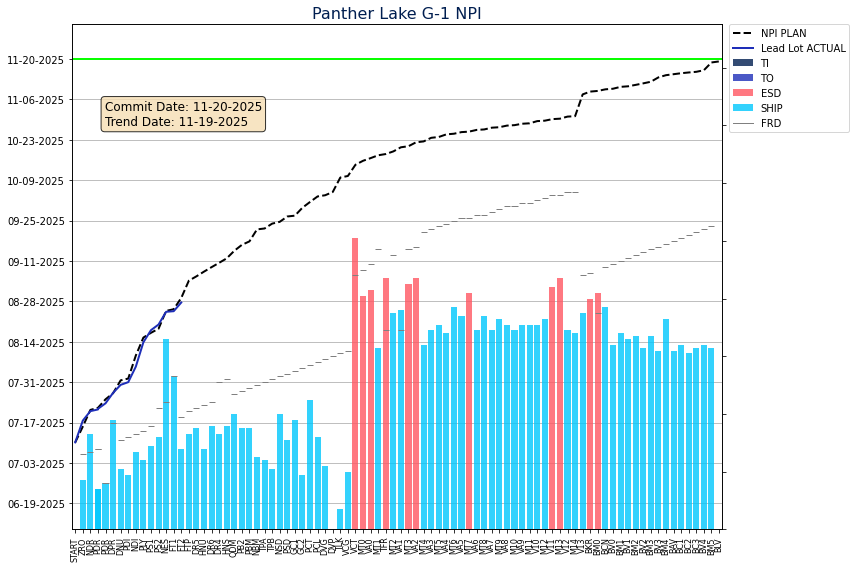

In [34]:
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# from matplotlib.lines import Line2D

fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.plot(plotdata['LAYER'], plotdata['PLAN'],color='black', label='NPI PLAN', linewidth=2, linestyle='--')

for idx, lot in enumerate(myGraph.lots):
    color = myGraph.trend_colors[idx % len(myGraph.trend_colors)]
    ax1.plot(plotdata['LAYER'], plotdata[f'{lot} ACTUAL'], color=color, label=f'{lot} ACTUAL', linewidth=2)

ax2 = ax1.twinx()

bar_columns = ['TI', 'TO', 'ESD', 'SHIP']

TrendLineColor = "#FF0011"
if commit_date >= trend_date:
    TrendLineColor = "#09FF00FF"

ax1.axhline(y=commit_date, color=TrendLineColor, linestyle='-', linewidth=2)

plotdata['BOTTOM'] = 0

for idx, bar in enumerate(bar_columns):

    ax2.bar(plotdata['LAYER'], plotdata[bar], bottom=plotdata['BOTTOM'], label=bar, color=myGraph.bar_colors[idx], alpha=0.8)
    plotdata['BOTTOM'] = plotdata[bar] + plotdata['BOTTOM']


for bar,frd in zip(plt.gca().patches,plotdata['FRD']):
    x = bar.get_x() + bar.get_width() / 2
    ax2.hlines(frd, x-bar.get_width()/2, x+bar.get_width()/2, color='grey', linewidth=1)

ax1.set_ylim(ymin_date, ymax_date)
ax2.set_ylim(ymin_val, ymax_val)

# Set the background color of the axes (the plot area) to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')
fig.patch.set_facecolor('white')

# Add a text box in the upper left
textstr = f'Commit Date: {commit_date.strftime("%m-%d-%Y")}'
textstr += f'\nTrend Date: {trend_date.strftime("%m-%d-%Y")}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.05, 0.85, textstr, transform=ax1.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='left', bbox=props)

ax1.set_xticklabels(plotdata['LAYER'], rotation=90, fontsize=8)
ax2.set_yticklabels([])
ax1.margins(x=0)
ax1.yaxis.grid(True)
ax1.yaxis.set_major_locator(mdates.DayLocator(interval=14)) 
ax1.yaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
frd_line = Line2D([0], [0], linestyle='-', color='grey', linewidth=1, label='FRD')

handles = handles1 + handles2 + [frd_line]
labels = labels1 + labels2 + ['FRD']
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01,1),borderaxespad=0.)


        
ax1.set_title(f'{myGraph.npi_name} NPI', color='#001E50', fontsize=16)
# Show plot
plt.tight_layout()
